In [30]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y


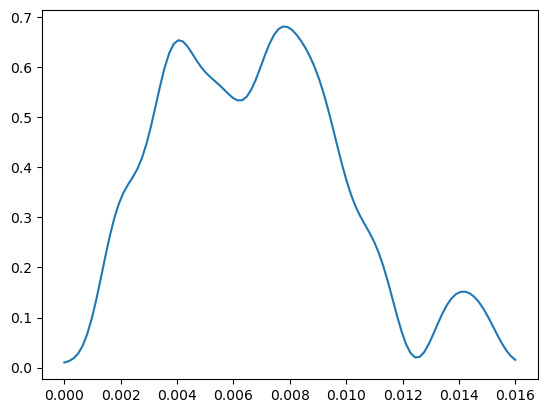

In [38]:
import matplotlib.pyplot as plt
plt.figure()
times = np.linspace(0, 16000e-6, 100)
plt.plot(times, B_line_mG(times))
plt.show()

In [39]:
from scipy import integrate as int

val, err = int.quad(B_line_mG, 0, 1000e-6) 

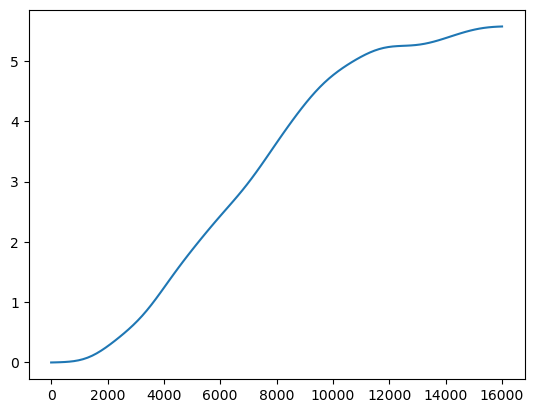

In [40]:
int_vals = []

for i in times:
    val, err = int.quad(B_line_mG, 0, i)
    int_vals.append(val)

plt.figure()
plt.plot(times*1e6, np.array(int_vals)*1e3)
plt.show()


In [42]:
display(np.array(times))

array([0.        , 0.00016162, 0.00032323, 0.00048485, 0.00064646,
       0.00080808, 0.0009697 , 0.00113131, 0.00129293, 0.00145455,
       0.00161616, 0.00177778, 0.00193939, 0.00210101, 0.00226263,
       0.00242424, 0.00258586, 0.00274747, 0.00290909, 0.00307071,
       0.00323232, 0.00339394, 0.00355556, 0.00371717, 0.00387879,
       0.0040404 , 0.00420202, 0.00436364, 0.00452525, 0.00468687,
       0.00484848, 0.0050101 , 0.00517172, 0.00533333, 0.00549495,
       0.00565657, 0.00581818, 0.0059798 , 0.00614141, 0.00630303,
       0.00646465, 0.00662626, 0.00678788, 0.00694949, 0.00711111,
       0.00727273, 0.00743434, 0.00759596, 0.00775758, 0.00791919,
       0.00808081, 0.00824242, 0.00840404, 0.00856566, 0.00872727,
       0.00888889, 0.00905051, 0.00921212, 0.00937374, 0.00953535,
       0.00969697, 0.00985859, 0.0100202 , 0.01018182, 0.01034343,
       0.01050505, 0.01066667, 0.01082828, 0.0109899 , 0.01115152,
       0.01131313, 0.01147475, 0.01163636, 0.01179798, 0.01195

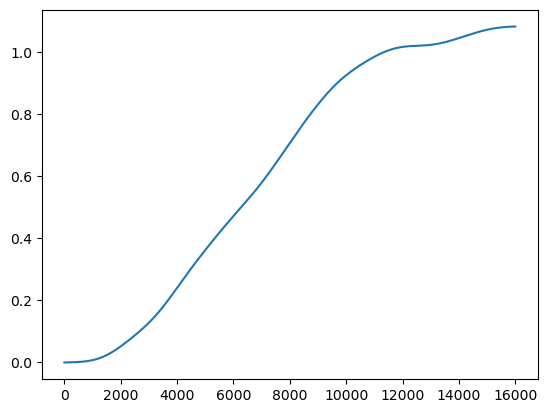

In [29]:
plt.figure()
plt.plot(times*1e6, np.mod(2*0.0971*np.array(int_vals)*1e3, 2))
plt.show()
